![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

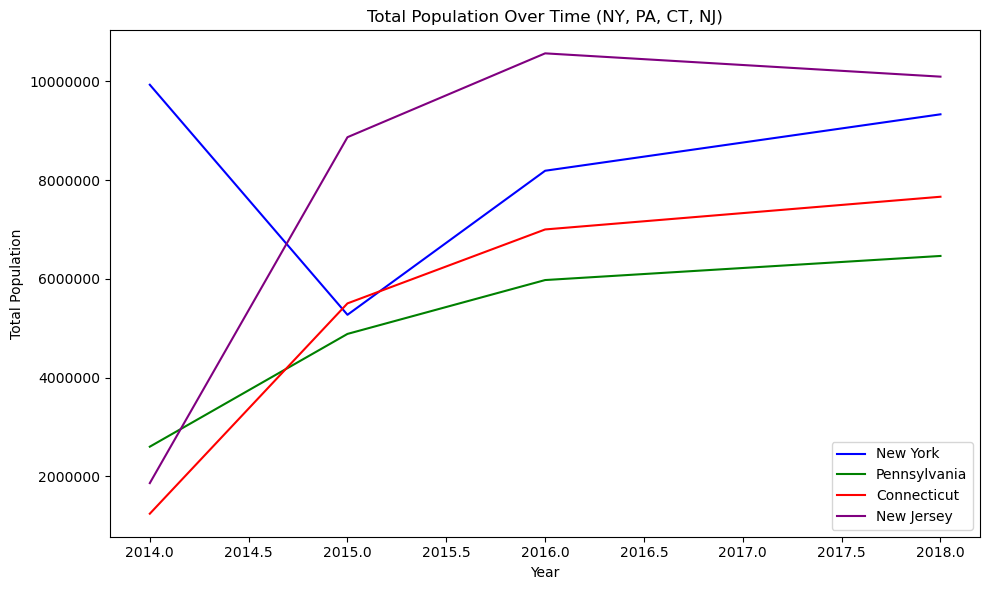

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("us-cities-top-1k-multi-year.csv")# Load dataset

states = ["New York", "Pennsylvania", "Connecticut", "New Jersey"]
df_filtered = df[df["State"].isin(states)]# Filter for selected states

grouped = df_filtered.groupby(["year", "State"])["Population"].sum().unstack()# Group and reshape data

plt.figure(figsize=(10, 6))

colors = {#specification for the colors to be used for the states
    "New York": "blue",
    "Pennsylvania": "green",
    "Connecticut": "red",
    "New Jersey": "purple"
}

for state in colors:#for loop to assign the colors to each state and then make the plot of their population
    plt.plot(grouped.index, grouped[state], label=state, color=colors[state])

plt.title("Total Population Over Time (NY, PA, CT, NJ)")#graph title
plt.xlabel("Year")#x-axis label
plt.ylabel("Total Population")#y-axis label
plt.legend()#legend
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [5]:
df.head()

State  Connecticut  New Jersey  New York  Pennsylvania
year                                                  
2014       1239817     1859793   9933332       2598080
2015       5502223     8870245   5271074       4883554
2016       7000555    10569472   8190332       5975094
2018       7663311    10097224   9334018       6463459


# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

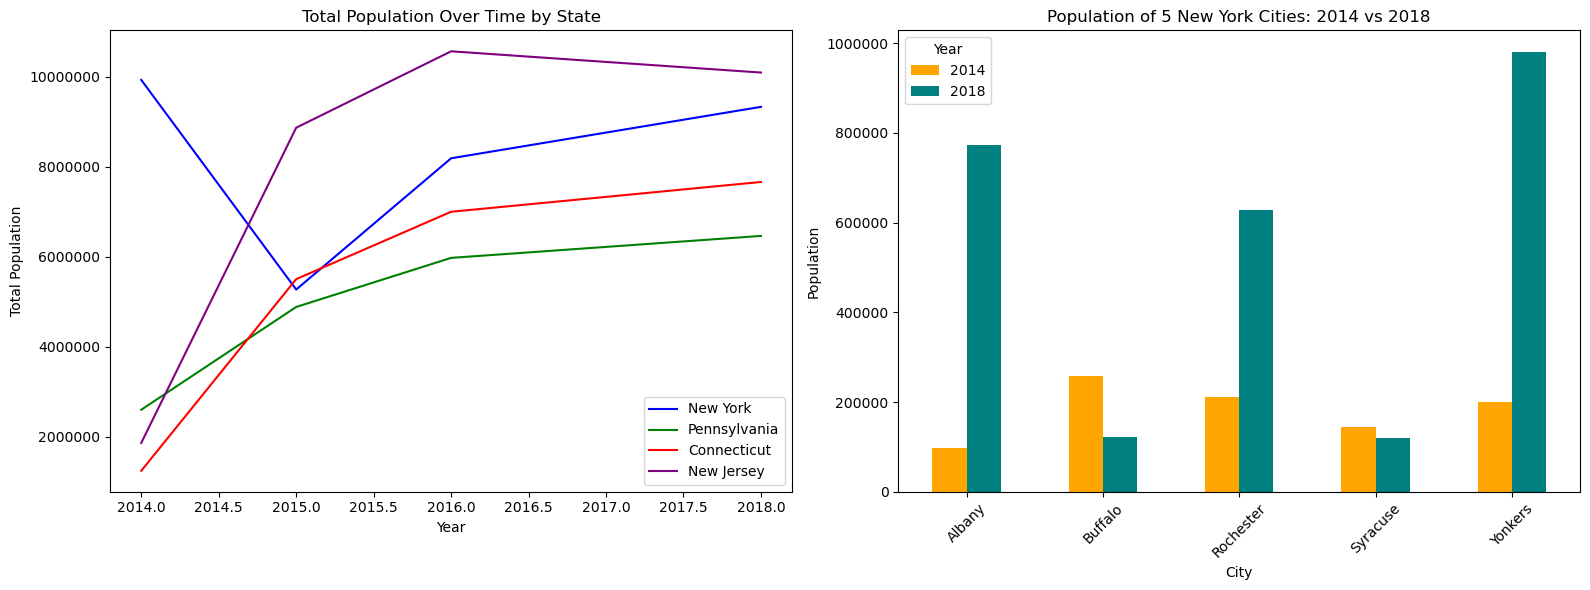

In [16]:

df = pd.read_csv("us-cities-top-1k-multi-year.csv")#load unflitered data set again
#repeat of question one to refer to this graph later 
states = ["New York", "Pennsylvania", "Connecticut", "New Jersey"]
df_states = df[df["State"].isin(states)]

grouped_states = df_states.groupby(["year", "State"])["Population"].sum().unstack()

ny_data = df[(df["State"] == "New York") & (df["year"].isin([2014, 2018]))]#Filter for New York only, and only years 2014 and 2018

cities = ["Albany", "Buffalo", "Rochester", "Yonkers", "Syracuse"]#list of the 5 cities I chose
ny_cities = ny_data[ny_data["City"].isin(cities)]#filter for just these 5 cities

grouped_cities = ny_cities.pivot(index="City", columns="year", values="Population")#Reshape so cities are rows and years are columns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))#comnining both graphs in one side-by-side image 
#plot information for graph 1
colors = {
    "New York": "blue",
    "Pennsylvania": "green",
    "Connecticut": "red",
    "New Jersey": "purple"
}

for state in colors:
    if state in grouped_states.columns:
        axes[0].plot(grouped_states.index, grouped_states[state], label=state, color=colors[state])

axes[0].set_title("Total Population Over Time by State")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Population")
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='y')
#plot information for graph 2
grouped_cities.plot(
    kind="bar",
    ax=axes[1],
    color=["orange", "teal"]#contrasting colors for easy vizualization
)

axes[1].set_title("Population of 5 New York Cities: 2014 vs 2018")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Population")
axes[1].legend(title="Year")
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].tick_params(axis='x', rotation=45)

# Final layout
plt.tight_layout()
plt.show()

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png